In [2]:
# 设置cell宽度
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
from numpy import log, sqrt
from pandas import concat
from pandas import DataFrame
from tqdm import tqdm


def calc_rc(symbol="000016.XSHG",
            date="2021-12-31",
            rolling_windows=30):
    data = get_index_weights(symbol, date=date)
    weight = data["weight"]
    weight /= 100
    universe = data.index.tolist()

    df = []
    for symbol in universe:
        data = get_price(security=symbol, end_date=date, count=rolling_windows + 1)
        tmp = log(data["close"] / data["close"].shift(1))
        tmp.name = symbol
        tmp = tmp.sort_index()
        tmp = tmp.iloc[1:].fillna(0.)
        df.append(tmp)
    df = concat(df, axis=1)

    # cov = df.cov()
    corr = df.corr().fillna(0.)
    sd = df.std(axis=0)

    su = 0
    sl = 0
    for i in range(1, len(universe)):
        for j in range(0, i):
            symbol_i = corr.index[i]
            symbol_j = corr.columns[j]
            w_i = weight[symbol_i]
            w_j = weight[symbol_j]
            rho = corr.loc[symbol_i, symbol_j]
            su += w_i * w_j * rho
            sl += w_i * w_j
    rc = su / sl
    return rc

In [194]:
symbol = "000300.XSHG"
date = "2021-12-31"
rolling_windows = 20
data = get_price(symbol, start_date="2016-01-01", end_date="2022-01-14")
df = []
for date in tqdm(data.index):
    date = date.strftime("%Y-%m-%d")
    rc = calc_rc(date=date, rolling_windows=rolling_windows)
    data = get_price(symbol, end_date=date, count=rolling_windows+1)
    price = data["close"].iloc[-1]
    hv = log(data["close"] / data["close"].shift(1)).iloc[1:].std() * sqrt(244) * 100
    df.append([date, rc, hv, price])

df = DataFrame(df)
df.columns = ["date", "RC{}".format(rolling_windows), "HV{}".format(rolling_windows), "沪深300"]


 21%|██        | 303/1470 [00:59<04:04,  4.76it/s]


 41%|████      | 605/1470 [01:59<02:47,  5.17it/s]


 62%|██████▏   | 907/1470 [02:59<01:56,  4.82it/s]


 82%|████████▏ | 1205/1470 [03:57<00:54,  4.87it/s]


100%|██████████| 1470/1470 [04:49<00:00,  5.30it/s]


20Day
40Day
60Day 
90Day

2016-01-01 2021-01-14

In [195]:
HS_20 = df

In [198]:
df2 = concat([HS_20.iloc[:, [1,2]], HS_40.iloc[:, [1,2]], HS_60.iloc[:, [1,2]], HS_90.iloc[:, [1,2]], HS_90.iloc[:, [3]]], axis=1)
df2.set_index(HS_90['date'], inplace=True)

In [199]:
df2.to_csv('沪深300.csv')

In [25]:
from datetime import datetime
start_date = "2016-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

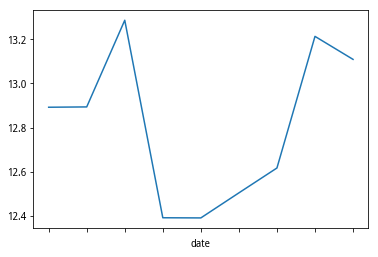

In [21]:
df.set_index("date")["HV40"].plot()